In [2]:
%run "/home/nichettg/Ubuntu/Laboratorio/moduli.py"

# 1. Lettura Dati

In [3]:
def nome (stringa):

    stringa_nuova = stringa.replace(f'./Data/','').replace('.csv','')
    return stringa_nuova

In [4]:
input_files = [f"./Data/{nome_file}" for nome_file in sorted(os.listdir(f'./Data'))]
data = {}

for input_file in input_files:
    letti = pd.read_csv(input_file)
    data[nome(input_file)] = {}


    for key in letti.keys():
        colonna = letti[key]
        try:
            # prova a convertirla in float
            data[nome(input_file)][key] = colonna.astype(float).to_numpy()
        except ValueError:
            # se non ci riesce, tieni le stringhe
            data[nome(input_file)][key] = colonna.astype(str).to_list()

#### Media

In [5]:
# prendi una sola volta l'asse x (sono tutti uguali)
distance_mean = np.array(
    next(iter(data.values()))["Distance_(pixels)"]
)

# raccogli tutti i gray value
gray_values = np.array([
    v["Gray_Value"] for v in data.values()
])

# media elemento per elemento
gray_mean = gray_values.mean(axis=0)

dati = {"pixel" : distance_mean,
        "intensita" : gray_mean}

# 2. Analisi Dati

In [6]:
err = 0

Fit Gaussiana
	ampiezza = 41.0 ± 0.4 
	mu = 621 ± 2 
	sigma = 278 ± 1 



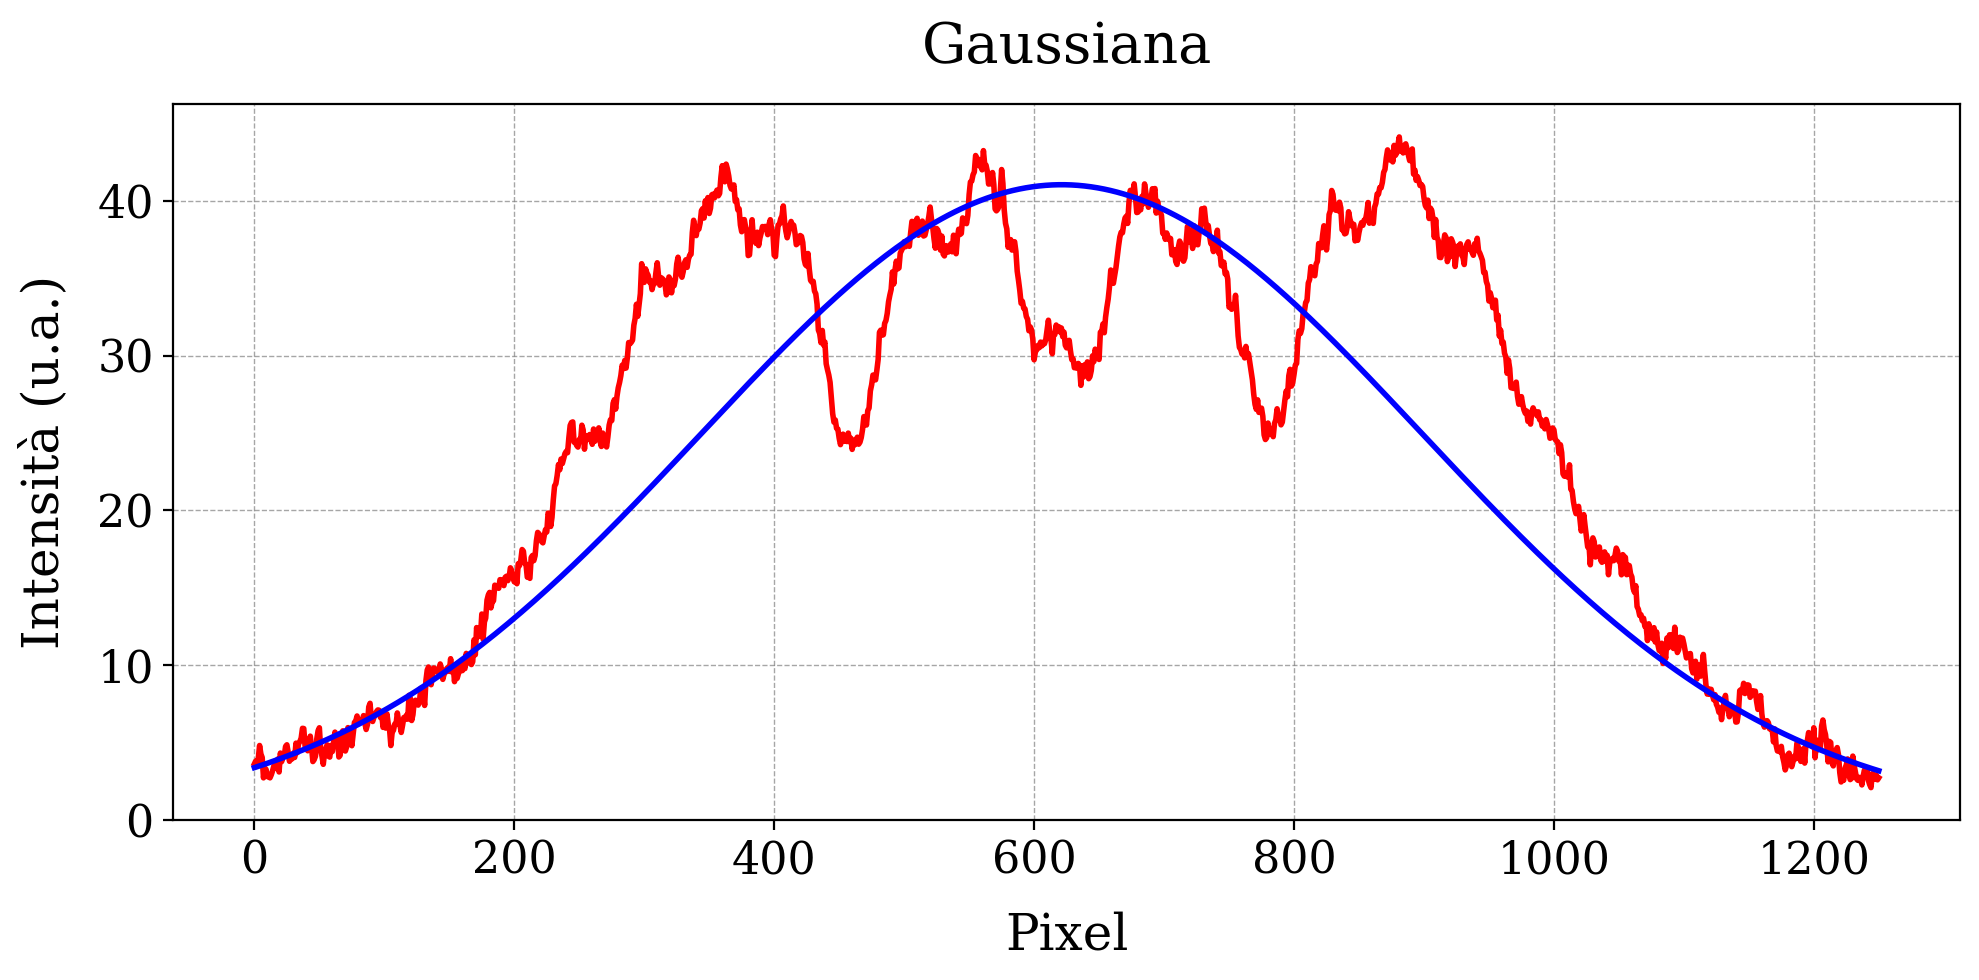

In [7]:
file_output = "analizzati.txt"
f.inizializza_output(file_output)
def gaussiana(B,x):
    return B[0] * np.exp(-(x - B[1])**2 / (2 * B[2]**2))
titolo = "Gaussiana"
fig,ax = plt.subplots(1, 1,  figsize=(10, 5))
xdata = [dati["pixel"],
        np.full_like(dati["pixel"],1/np.sqrt(12))]
ydata = [dati["intensita"],
        np.sqrt( err*2 + (0.05*dati["intensita"])**2 )]
gf.parametri_grafico(ax,titolo,xlabel="Pixel",ylabel="Intensità (u.a.)")
ax.plot(xdata[0],ydata[0],color="red")

x = xdata[0]
y = ydata[0]
A0 = np.max(y)
mu0 = x[np.argmax(y)]
sigma0 = (np.max(x) - np.min(x)) / 6
beta0 = [A0, mu0, sigma0]

anal = f.fit(xdata,ydata,gaussiana,beta0, chi=False)
par = [anal[0][0], anal[1][0], anal[2][0]]

f.chi_quadro(xdata[0],ydata[0],xdata[1],par,gaussiana,file_output,titolo)

x = np.linspace(np.min(xdata[0]), np.max(xdata[0]), 500)
y = gaussiana([anal[0][0], anal[1][0], anal[2][0]], x)
ax.plot(x, y, color="blue")

print(f"Fit {titolo}")
print(f"\tampiezza = {gf.formatta_errore(anal[0][0],anal[0][1],txt=True)}")
print(f"\tmu = {gf.formatta_errore(anal[1][0],anal[1][1],txt=True)}")
print(f"\tsigma = {gf.formatta_errore(anal[2][0],anal[2][1],txt=True)}\n")

gf.salva_grafico(fig,"gaussiana.pdf")

del xdata,ydata,x,y